# Diseño con polos y ceros
**Análisis y procesamiento de Señales** - Bioingeniería - Fac. de Ingeniería - UNSTA - 2026

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
ecg = np.loadtxt("./ECG.txt")

fs = 200
N = len(ecg)
n = np.arange(N)
t = n/fs

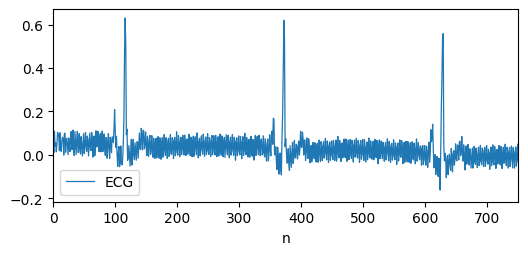

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 2.5))

ax.plot(ecg, linewidth=0.9, label="ECG")
ax.set_xlim([0, 750])
ax.set_xlabel("n")
ax.legend()

In [4]:
def obtain_ecg_fft(ecg, fs, N, w_noise = None, amax=60, ecg_clean=None):
  ecg_fft = np.fft.fft(ecg)
  f = (fs/N)*n

  plt.plot(f[:int(N/2)], np.abs(ecg_fft)[:int(N/2)])

  if w_noise:
    f_noise = (w_noise * fs) / (2 * np.pi)
    plt.plot([f_noise, f_noise], [0, amax], linewidth=1, color="red")

  if ecg_clean is not None:
    ecg_fft_clean = np.fft.fft(ecg_clean)
    plt.plot(f[:int(N/2)], np.abs(ecg_fft_clean)[:int(N/2)], linewidth=0.8,
             label="Original", alpha=0.8, color="orange")

  plt.xlabel("f [Hz]");

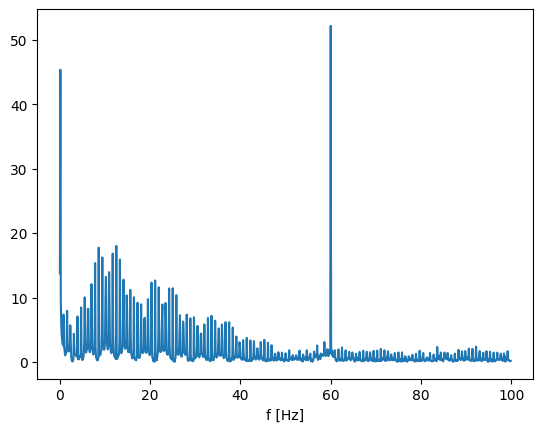

In [5]:
obtain_ecg_fft(ecg, fs, N)

Identificamos la frecuencia angular donde ocurre el ruido:

In [6]:
w60 = 60 * 2 * np.pi / fs

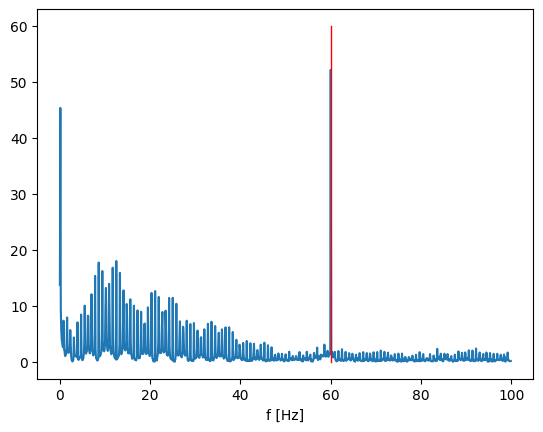

In [7]:
obtain_ecg_fft(ecg, fs, N, w60)

Vamos a poner un cero en ese punto:

In [8]:
def obtain_complex_number(w, v = 1):
  a = v * np.cos(w)
  b = v * np.sin(w)

  return complex(a, b), complex(a, -b)

In [9]:
c60, c60_conj = obtain_complex_number(w60)
p0, p0_conj = obtain_complex_number(0, v=0)

In [10]:
def obtain_coefs(zeros, poles):
  b = np.polynomial.polynomial.polyfromroots(zeros)
  b = b.astype("float")

  a = np.polynomial.polynomial.polyfromroots(poles)
  a = a.astype("float")

  # Por como genera los valores `np.polynomial.polynomial.polyfromroots`,
  # debemos invertir el array para poder usarlo como coeficiente de los
  # filtros

  b = np.flip(b)
  a = np.flip(a)

  a_norm = a / a[0]
  b_norm = b / a[0]

  return a_norm, b_norm

Normalizemos los coeficientes al primer elemento:

In [11]:
a, b = obtain_coefs((c60, c60_conj), (p0, p0_conj))

/tmp/ipykernel_22768/4130786868.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  b = b.astype("float")
/tmp/ipykernel_22768/4130786868.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  a = a.astype("float")


Veamos el filtro como diagrama de polo y cero, y como respuesta en frecuencia:

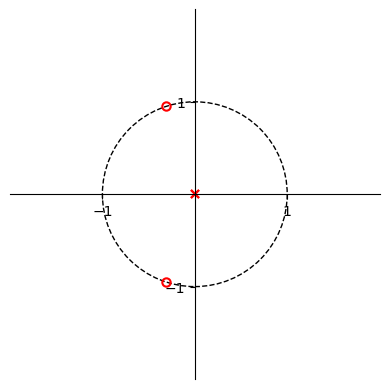

In [12]:
from zplane_graph import zplane
zplane(b, a);

In [13]:
def obtain_response(b, a, fs, N):
    w, H = sp.signal.freqz(b, a, fs=fs, worN=N)
    return w, H

def plot_response(w, H, fs, ylim_limits=(-40, 10)):
  fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
  ax[0].plot(w, 20*np.log10(abs(H)))
  ax[1].plot(w, np.angle(H, deg=True))
  ax[0].grid("True")
  ax[1].grid("True")

  ax[0].set_ylabel("|H( $\\omega$ )| dB")
  ax[1].set_ylabel("Fase (deg)")
  ax[0].set_xlabel("f [Hz]")
  ax[1].set_xlabel("f [Hz]")

  ax[0].set_ylim(ylim_limits)
  ax[0].set_xlim([0, fs/2])
  ax[1].set_xlim([0, fs/2])

  plt.tight_layout();

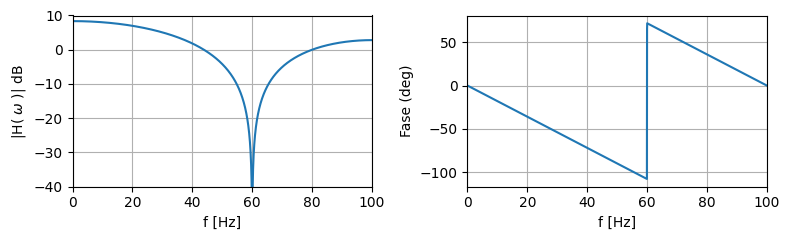

In [14]:
w, H = obtain_response(b, a, fs, N)

plot_response(w, H, fs)

Filtremos la señal:

In [15]:
ecg_filt = sp.signal.lfilter(b, a, ecg)

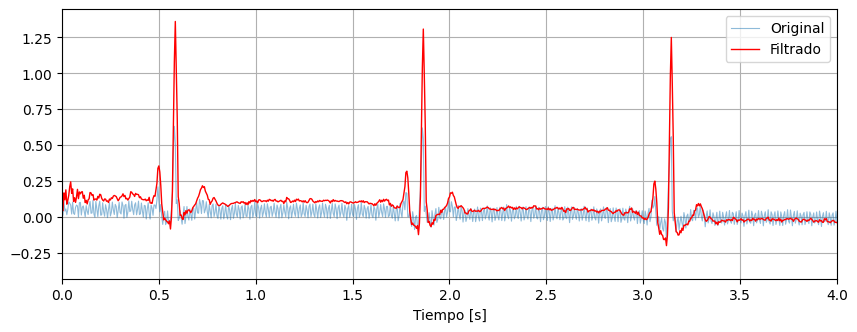

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(t, ecg, linewidth=0.8, label="Original", alpha=0.5)
ax.plot(t, ecg_filt, linewidth=1, color="red", label="Filtrado")
ax.set_xlim([0, 4])
ax.set_xlabel("Tiempo [s]")
ax.legend()
ax.grid(True)

Vemos la respuesta al impulso:

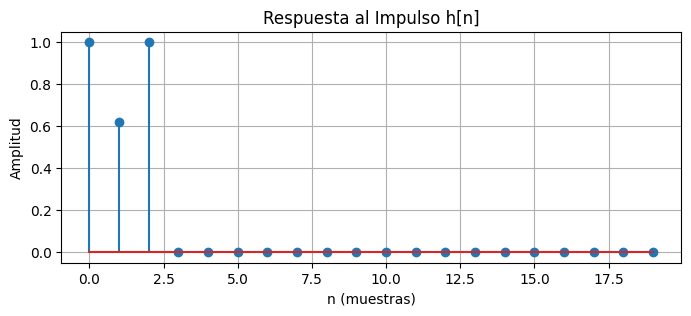

In [17]:
def plot_impulse_response(b, a, M=50):
    # Creamos un impulso unitario
    impulse = np.zeros(M)
    impulse[0] = 1

    # Calculamos la respuesta al impulso usando lfilter
    h = sp.signal.lfilter(b, a, impulse)

    # Graficamos
    plt.figure(figsize=(8, 3))
    plt.stem(h)
    plt.title("Respuesta al Impulso h[n]")
    plt.xlabel("n (muestras)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

    return h

# Calculamos y graficamos para los coeficientes actuales
_ = plot_impulse_response(b, a, M=20)

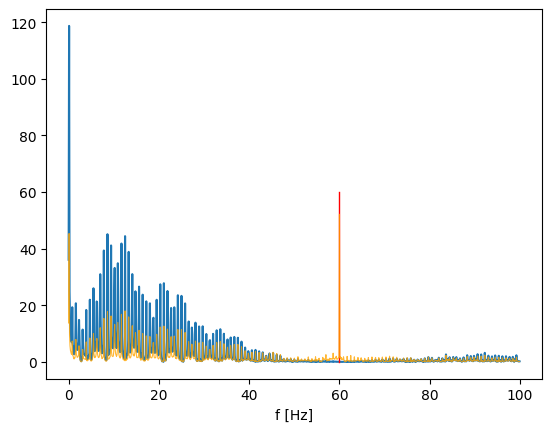

In [18]:
obtain_ecg_fft(ecg_filt, fs, N, w60, ecg_clean=ecg)

Vemos que filtramos la señal, pero la distorsionamos.

Previo a ajustar eso, vamos a ver si podemos **estrechar el notch** agregando polos en $0.57\pi$ y $0.63\pi$ (57 Hz y 63 Hz).

In [19]:
w57 = 57*2*np.pi/200
w63 = 63*2*np.pi/200

p57, p57_conj = obtain_complex_number(w57, v=0.5)
p63, p63_conj = obtain_complex_number(w63, v=0.5)

Tenemos 2 ceros, y 4 polos, debemos igualar, entonces agregamos dos ceros al origen.

In [20]:
c0, _ = obtain_complex_number(0, v=0)

In [21]:
a, b = obtain_coefs((c60, c60_conj, c0, c0), (p57, p57_conj, p63, p63_conj))

/tmp/ipykernel_22768/4130786868.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  b = b.astype("float")
/tmp/ipykernel_22768/4130786868.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  a = a.astype("float")


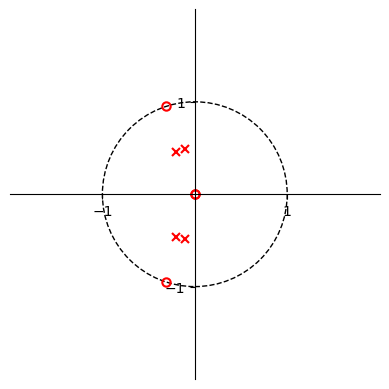

In [22]:
zplane(b, a);

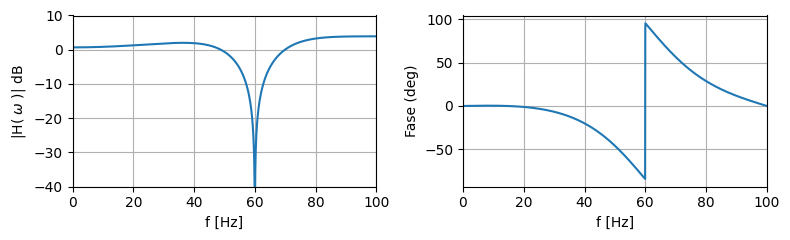

In [23]:
w, H = obtain_response(b, a, fs, N)

plot_response(w, H, fs)

Ahí se **achicó el ancho de la zona de bloqueo**. Vamos a poner un **cero más en 0 Hz** para levantar la primera parte.

In [24]:
p0, _ = obtain_complex_number(0, v=0.2)

In [25]:
# No olvidar igualar polos y ceros
a, b = obtain_coefs((c60, c60_conj, c0, c0, c0),
 (p57, p57_conj, p63, p63_conj, p0))

/tmp/ipykernel_22768/4130786868.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  b = b.astype("float")
/tmp/ipykernel_22768/4130786868.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  a = a.astype("float")


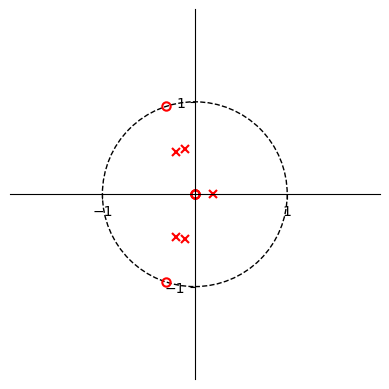

In [26]:
zplane(b, a);

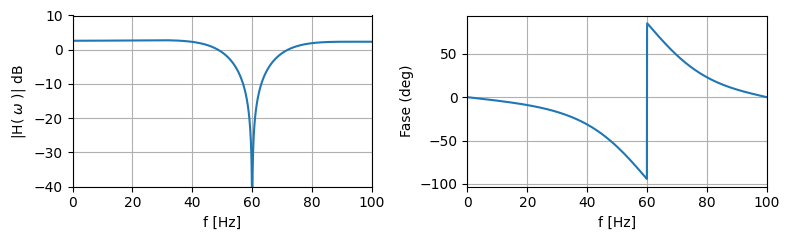

In [27]:
w, H = obtain_response(b, a, fs, N)

plot_response(w, H, fs)

Vemos que la **fase se mantiene bastante lineal** en la zona de paso. Por lo que estamos conformes con este filtro.

Vamos a **mover la respuesta a 0 dB** para que no se amplifique. Para ello dividimos por el valor de $H(0)$ a toda la respuesta (podría usarse un valor medio de la banda de paso).

In [28]:
H_norm = float(H[0])

/tmp/ipykernel_22768/2826431299.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  H_norm = float(H[0])


In [29]:
b = b / H_norm

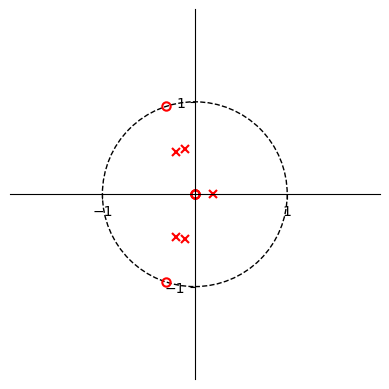

In [30]:
zplane(b, a);

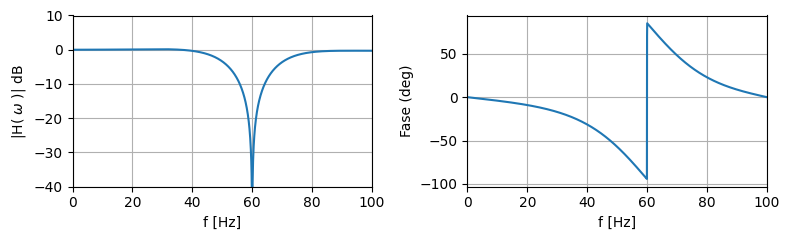

In [31]:
w, H = obtain_response(b, a, fs, N)

plot_response(w, H, fs)

Veamos la respuesta al impulso

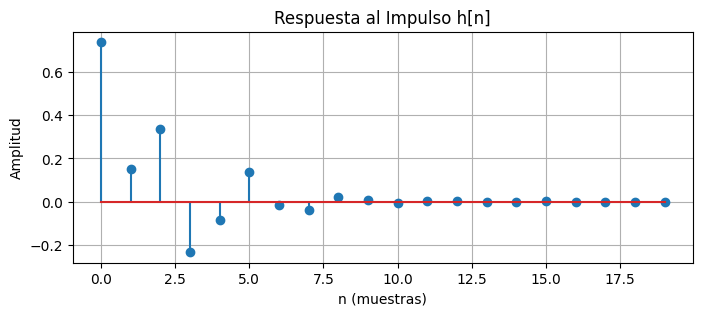

In [32]:
h_resp = plot_impulse_response(b, a, M=20)

Con los coeficientes, podemos **aplicar el filtro**:

In [33]:
ecg_filt = sp.signal.lfilter(b, a, ecg)

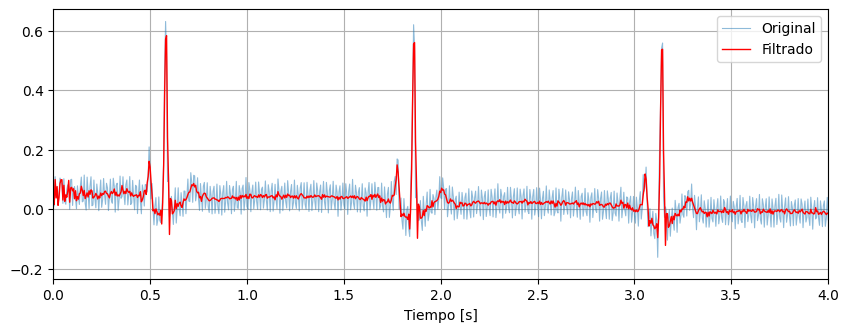

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(t, ecg, linewidth=0.8, label="Original", alpha=0.5)
ax.plot(t, ecg_filt, linewidth=1, color="red", label="Filtrado")
ax.set_xlim([0, 4])
ax.set_xlabel("Tiempo [s]")
ax.legend()
ax.grid(True)

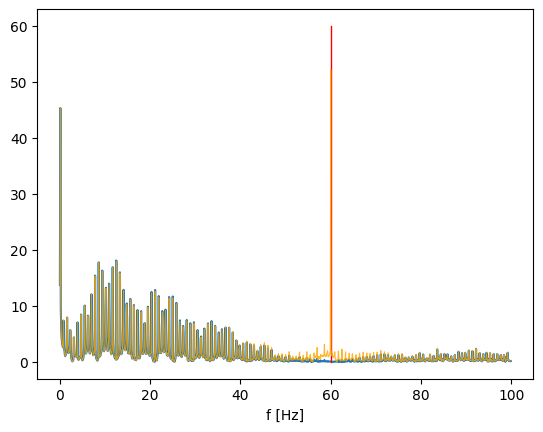

In [35]:
obtain_ecg_fft(ecg_filt, fs, N, w60, ecg_clean=ecg)

### Obteniendo un filtro FIR con la respuesta al impulso

Si recordamos, los filtros FIR tienen como coeficientes la respuesta al impulso, por lo que podemos **convertir un filtro IIR en un filtro FIR** tomando la respuesta al impulso y **truncando** una cantidad finita de valores.

Si por ejemplo tomamos los **20 primeros coeficientes:**


In [36]:
b = h_resp[:20]

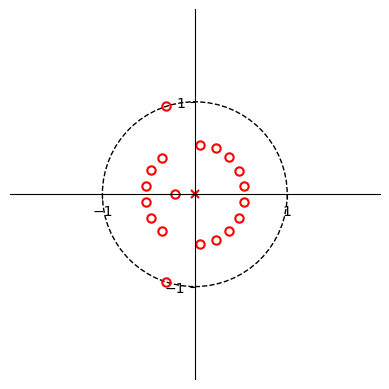

In [37]:
zplane(b, (1,));

In [38]:
w, H = obtain_response(b, (1,), fs, N)

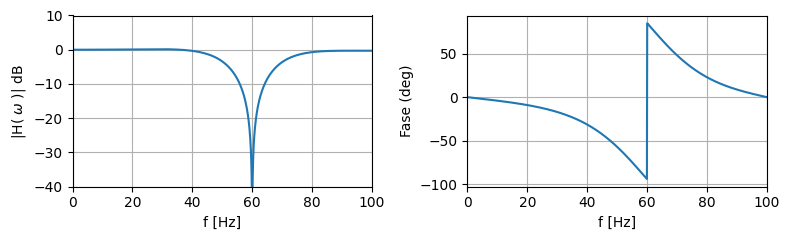

In [39]:
plot_response(w, H, fs)

In [40]:
ecg_filt_fir = sp.signal.lfilter(b, (1,), ecg)

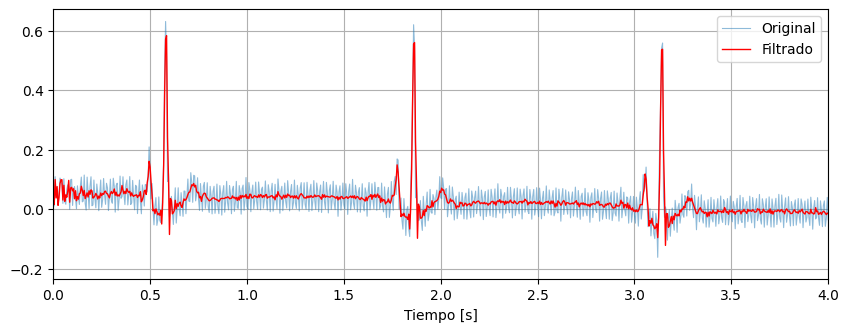

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(t, ecg, linewidth=0.8, label="Original", alpha=0.5)
ax.plot(t, ecg_filt_fir, linewidth=1, color="red", label="Filtrado")
ax.set_xlim([0, 4])
ax.set_xlabel("Tiempo [s]")
ax.legend()
ax.grid(True)

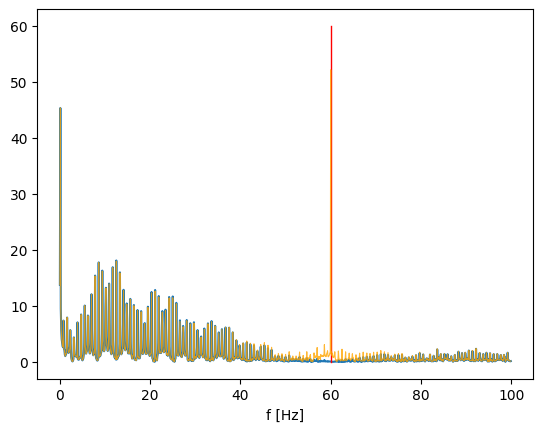

In [42]:
obtain_ecg_fft(ecg_filt_fir, fs, N, w60, ecg_clean=ecg)